In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/upi_transactions_2024.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (250000, 17)
Columns: ['transaction id', 'timestamp', 'transaction type', 'merchant_category', 'amount (INR)', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'fraud_flag', 'hour_of_day', 'day_of_week', 'is_weekend']


,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   transaction id      250000 non-null  str  
 1   timestamp           250000 non-null  str  
 2   transaction type    250000 non-null  str  
 3   merchant_category   250000 non-null  str  
 4   amount (INR)        250000 non-null  int64
 5   transaction_status  250000 non-null  str  
 6   sender_age_group    250000 non-null  str  
 7   receiver_age_group  250000 non-null  str  
 8   sender_state        250000 non-null  str  
 9   sender_bank         250000 non-null  str  
 10  receiver_bank       250000 non-null  str  
 11  device_type         250000 non-null  str  
 12  network_type        250000 non-null  str  
 13  fraud_flag          250000 non-null  int64
 14  hour_of_day         250000 non-null  int64
 15  day_of_week         250000 non-null  str  
 16  is_weekend          250000 non-

In [3]:
df.describe()

,amount (INR),fraud_flag,hour_of_day,is_weekend
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,1311.756036,0.001920,14.681032,0.285348
std,1848.059224,0.043776,5.188304,0.451581
min,10.000000,0.000000,0.000000,0.000000
25%,288.000000,0.000000,11.000000,0.000000
50%,629.000000,0.000000,15.000000,0.000000
75%,1596.000000,0.000000,19.000000,1.000000
max,42099.000000,1.000000,23.000000,1.000000


fraud_flag
0    249520
1       480
Name: count, dtype: int64

Fraud percentage: 0.19%


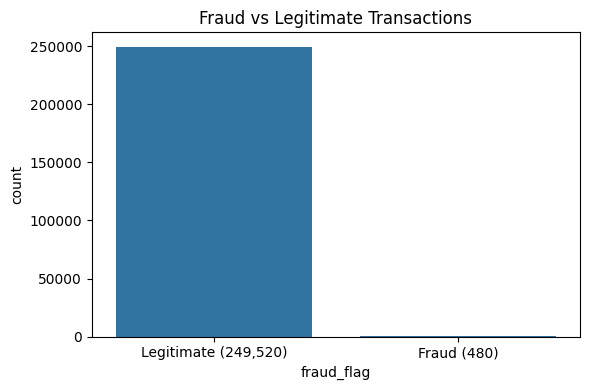

In [4]:
fraud_count = df['fraud_flag'].value_counts()
print(fraud_count)
print(f"\nFraud percentage: {df['fraud_flag'].mean()*100:.2f}%")

# Visualize
plt.figure(figsize=(6,4))
sns.countplot(x='fraud_flag', data=df)
plt.title('Fraud vs Legitimate Transactions')
plt.xticks([0,1], ['Legitimate (249,520)', 'Fraud (480)'])
plt.tight_layout()
plt.savefig('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/class_distribution.png')
plt.show()

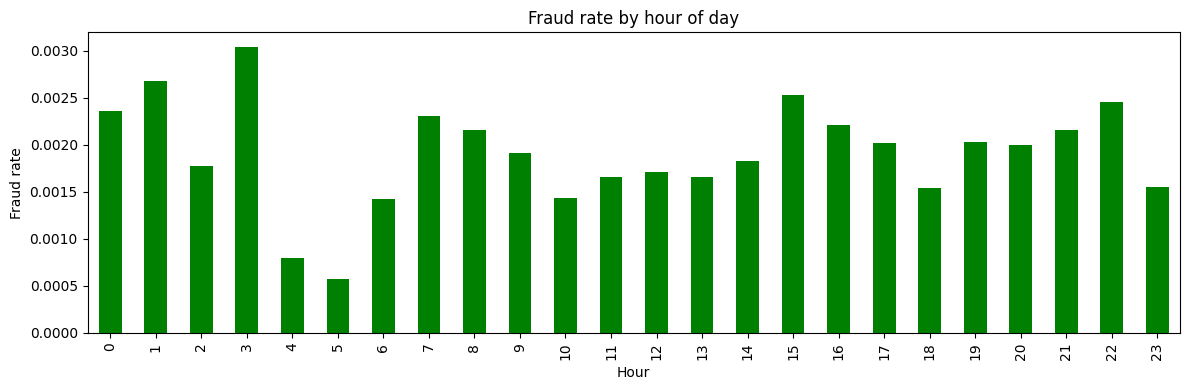

In [5]:
#Fraud by hour (night fraud pattern)
plt.figure(figsize=(12,4))
hourly = df.groupby('hour_of_day')['fraud_flag'].mean()
hourly.plot(kind='bar', color='green')
plt.title('Fraud rate by hour of day')
plt.xlabel('Hour')
plt.ylabel('Fraud rate')
plt.tight_layout()
plt.show()

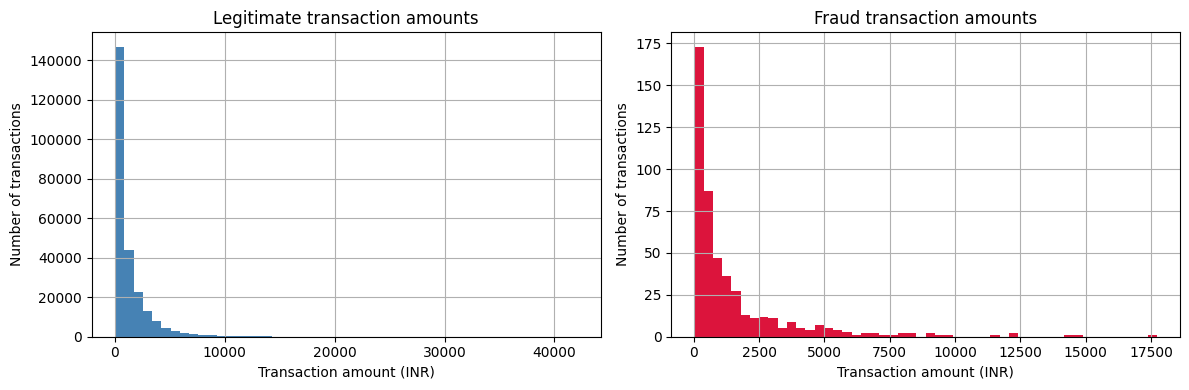

Avg legit amount: ₹ 1311.4
Avg fraud amount: ₹ 1499.23


In [6]:
# Amount distribution: fraud vs legit
fig, axes = plt.subplots(1,2, figsize=(12,4))

df[df['fraud_flag']==0]['amount (INR)'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Legitimate transaction amounts')
axes[0].set_xlabel('Transaction amount (INR)')
axes[0].set_ylabel('Number of transactions')

df[df['fraud_flag']==1]['amount (INR)'].hist(bins=50, ax=axes[1], color='crimson')
axes[1].set_title('Fraud transaction amounts')
axes[1].set_xlabel('Transaction amount (INR)')
axes[1].set_ylabel('Number of transactions')

plt.tight_layout()
plt.show()

print("Avg legit amount: ₹", df[df['fraud_flag']==0]['amount (INR)'].mean().round(2))
print("Avg fraud amount: ₹", df[df['fraud_flag']==1]['amount (INR)'].mean().round(2))

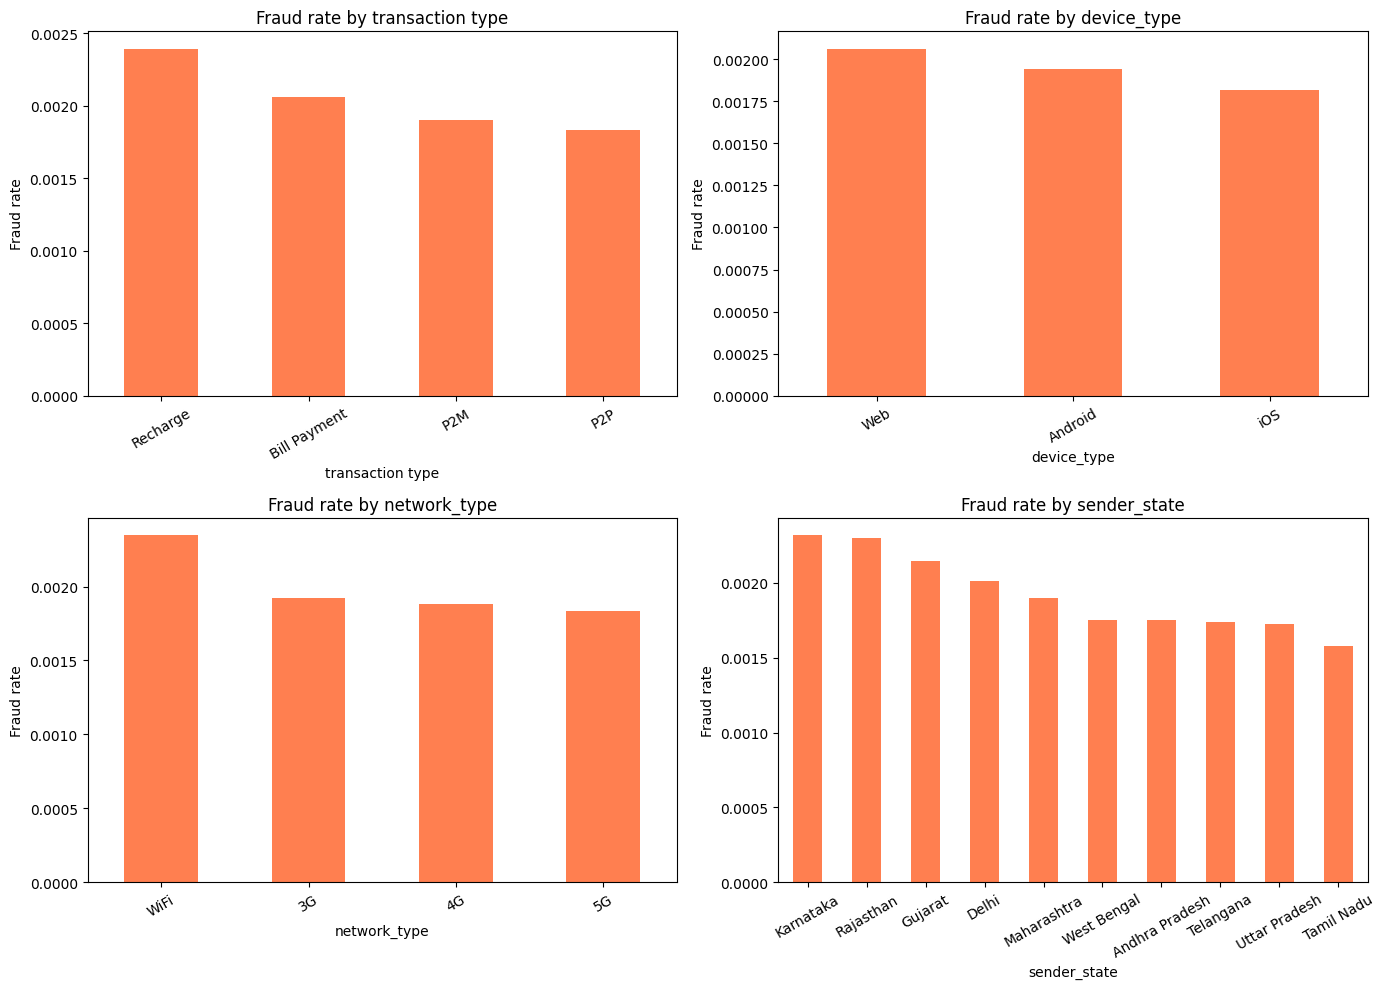

In [10]:
# Fraud by category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(),
                   ['transaction type', 'device_type', 'network_type', 'sender_state']):
    rates = df.groupby(col)['fraud_flag'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='coral')
    ax.set_title(f'Fraud rate by {col}')
    ax.set_ylabel('Fraud rate')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/fraud_by_category.png')
plt.show()

In [11]:
# Drop ID columns, check what goes into model
drop_cols = ['transaction id', 'timestamp', 'transaction_status']
print("Columns to DROP before training:", drop_cols)
print("\nColumns to ENCODE (categorical):")
print(['transaction type','merchant_category','sender_age_group',
       'receiver_age_group','sender_state','sender_bank',
       'receiver_bank','device_type','network_type','day_of_week'])
print("\nColumns ready as-is (numeric):")
print(['amount (INR)', 'hour_of_day', 'is_weekend'])
print("\nTarget column: fraud_flag")

Columns to DROP before training: ['transaction id', 'timestamp', 'transaction_status']

Columns to ENCODE (categorical):
['transaction type', 'merchant_category', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'day_of_week']

Columns ready as-is (numeric):
['amount (INR)', 'hour_of_day', 'is_weekend']

Target column: fraud_flag
